In [112]:
pip install pretty_midi

In [ ]:
import os
import json
import random
from pathlib import Path

# Core ML libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi

# PyTorch with LSTM sequence modeling
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

In [114]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [115]:
def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()

print('PyTorch version:', torch.__version__)
print('WE GOT THE:', device)

PyTorch version: 2.10.0+cu128
WE GOT THE: cuda


In [ ]:
# Dataset wrapper for piano roll representations
# Input: 128 timesteps × 88 piano keys (binary activation per frame)
class PianoRollDataset(Dataset):
    def __init__(self, npy_file):
        self.data = np.load(npy_file)
        self.data = torch.from_numpy(self.data).float()
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

In [ ]:
# LSTM Autoencoder architecture
# - Encoder: LSTM (88 → 256 dim, 2 layers) → FC to latent space (64 dim)
# - Decoder: FC (64 → 256) → LSTM (256 → 88, 2 layers) for reconstruction
# - Latent bottleneck (64d) enforces learned representation
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=88, hidden_dim=256, latent_dim=64, num_layers=2):
        super(LSTMAutoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.encoder_lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc_latent = nn.Linear(hidden_dim, latent_dim)

        self.decoder_lstm = nn.LSTM(latent_dim, hidden_dim, num_layers, batch_first=True)
        self.fc_output = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        z = self.fc_latent(h_n[-1])
        return z

    def decode(self, z, seq_len=128):
        z_repeated = z.unsqueeze(1).repeat(1, seq_len, 1)
        out, _ = self.decoder_lstm(z_repeated)
        return self.fc_output(out)


    def forward(self, x):        
        z = self.encode(x)
        return self.decode(z)

In [ ]:
# Focal Loss: focuses training on hard negatives to improve sparsity
# alpha=0.9, gamma=2.0: Prioritizes rare piano notes, reduces false positives
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss

        return torch.mean(F_loss)

In [ ]:
# Training loop with adaptive learning rate and early stopping via validation loss
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, device='cuda'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = FocalLoss(alpha=0.9, gamma=2.0)  # Binary CE with hardness weighting
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': []}

    main_pbar = tqdm(range(epochs), desc="Overall Progress")

    for epoch in main_pbar:
        model.train()
        train_loss = 0

        batch_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)
        for batch in batch_pbar:
            batch = batch.to(device)

            optimizer.zero_grad()
            output = model(batch)
            loss = criterion(output, batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            batch_pbar.set_postfix(batch_loss=f"{loss.item():.4f}")

        avg_train = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                output = model(batch)
                loss = criterion(output, batch)
                val_loss += loss.item()

        avg_val = val_loss / len(val_loader)

        scheduler.step(avg_val)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        current_lr = optimizer.param_groups[0]['lr']
        main_pbar.set_postfix({
            'T-Loss': f"{avg_train:.4f}",
            'V-Loss': f"{avg_val:.4f}",
            'LR': f"{current_lr:.6f}"
        })


    return history    

In [ ]:
# Sample generation: random latent vector decoded to piano roll
# threshold=0.3: Probability cutoff to binarize reconstruction
def generate_sample(model, device='cuda', threshold=0.3):
    model.eval()
    with torch.no_grad():
        z = torch.randn(1, model.latent_dim).to(device)  # 64-dim Gaussian sample
        logits = model.decode(z)

        probs = torch.sigmoid(logits)
        binary_roll = (probs > threshold).cpu().numpy().squeeze()

    return binary_roll 

In [ ]:
# Full training pipeline: Load data, train LSTM autoencoder, save best model
# Batch size 32, 60 epochs with validation-based early stopping
# Uses gradient clipping (max_norm=1.0) to stabilize LSTM training
def run():

In [122]:
def plot_loss_curve(history, save_path='/content/drive/MyDrive/CSE425 Project/output/task1/loss_curve.png'):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    plt.figure(figsize=(10, 6))
    plt.plot(history['train'], label='Train Loss', linewidth=2)
    plt.plot(history['val'], label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('LSTM Autoencoder Training History', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"Loss curve saved to {save_path}")
    plt.show()

In [ ]:
def piano_roll_to_midi(piano_roll, output_path, velocity=80, tempo=120, threshold=0.5, max_note_length=12, min_note_length=5):
    # Convert binary piano roll to MIDI: threshold=0.5 for binarization
    # min_note_length=5 frames (~0.625s): Remove noise notes
    # max_note_length=12 frames (~1.5s): Prevent sustained single chords
    # frame_length = 60/120/4 = 0.125s per frame (16 frames per 2 seconds at 120 BPM)
    midi = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=0, name='Piano')

    frame_length = 60.0 / tempo / 4 
    
    binary_roll = (piano_roll > threshold).astype(int)

    for pitch in range(binary_roll.shape[1]):
        midi_pitch = 21 + pitch  # A0 = MIDI 21
        in_note = False
        note_start = 0
        
        for t in range(binary_roll.shape[0]):
            if binary_roll[t, pitch] > 0 and not in_note:
                in_note = True
                note_start = t
            elif binary_roll[t, pitch] == 0 and in_note:
                note_length = t - note_start
                if note_length >= min_note_length:
                    note_end = min(t, note_start + max_note_length)
                    start_time = note_start * frame_length
                    end_time = note_end * frame_length
                    note = pretty_midi.Note(velocity=velocity, pitch=midi_pitch, start=start_time, end=end_time)
                    instrument.notes.append(note)
                in_note = False
        
        if in_note:
            note_length = binary_roll.shape[0] - note_start
            if note_length >= min_note_length:
                note_end = min(binary_roll.shape[0], note_start + max_note_length)
                start_time = note_start * frame_length
                end_time = note_end * frame_length
                note = pretty_midi.Note(velocity=velocity, pitch=midi_pitch, start=start_time, end=end_time)
                instrument.notes.append(note)

    midi.instruments.append(instrument)
    midi.write(output_path)
    print(f"MIDI saved to {output_path}")

def generate_and_save_samples(model, device, num_samples=5, save_dir='/content/drive/MyDrive/CSE425 Project/output/task1/generated', 
                               threshold=0.5, max_note_length=12, min_note_length=5, velocity=80, tempo=120):
    os.makedirs(save_dir, exist_ok=True)

    model.eval()
    with torch.no_grad():
        for i in range(num_samples):
            z = torch.randn(1, model.latent_dim).to(device)  # 64-dim Gaussian
            logits = model.decode(z)
            probs = torch.sigmoid(logits)
            binary_roll = probs.cpu().numpy().squeeze()

            midi_path = os.path.join(save_dir, f'sample_{i+1:02d}.mid')
            piano_roll_to_midi(binary_roll, midi_path, velocity=velocity, tempo=tempo, 
                             threshold=threshold, max_note_length=max_note_length, 
                             min_note_length=min_note_length)

    print(f"Generated {num_samples} samples in {save_dir}")

Using device: cuda


Epochs:   0%|          | 0/60 [00:00<?, ?epoch/s]

Saved new best model at epoch 1 with val loss 0.0480
Saved new best model at epoch 3 with val loss 0.0477
Saved new best model at epoch 4 with val loss 0.0464
Saved new best model at epoch 5 with val loss 0.0449
Saved new best model at epoch 6 with val loss 0.0449
Saved new best model at epoch 7 with val loss 0.0435
Saved new best model at epoch 8 with val loss 0.0390
Saved new best model at epoch 9 with val loss 0.0388
Saved new best model at epoch 10 with val loss 0.0378
Saved new best model at epoch 11 with val loss 0.0366
Saved new best model at epoch 12 with val loss 0.0360
Saved new best model at epoch 13 with val loss 0.0353
Saved new best model at epoch 14 with val loss 0.0345
Saved new best model at epoch 15 with val loss 0.0341
Saved new best model at epoch 16 with val loss 0.0338
Saved new best model at epoch 17 with val loss 0.0333
Saved new best model at epoch 18 with val loss 0.0332
Saved new best model at epoch 19 with val loss 0.0329
Saved new best model at epoch 20 wit

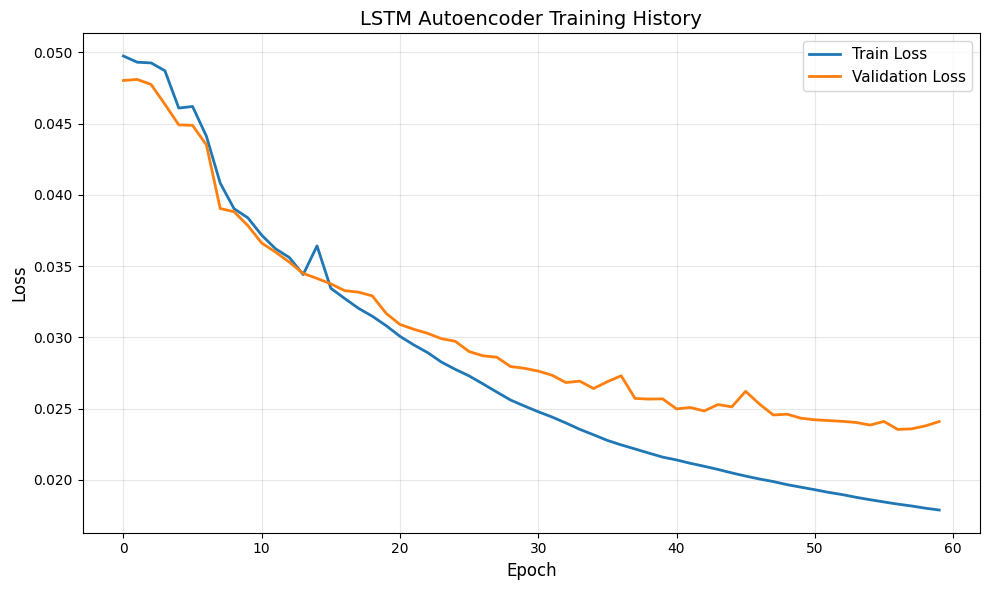

MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_01.mid
MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_02.mid
MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_03.mid
MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_04.mid
MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_05.mid
Generated 5 samples in /content/drive/MyDrive/CSE425 Project/output/task1/generated


In [124]:
history, model, device = run()
plot_loss_curve(history)
generate_and_save_samples(model, device, num_samples=5)

In [125]:
print(f"The trained model is currently on: {next(model.parameters()).device}")

The trained model is currently on: cuda:0


In [ ]:
model = LSTMAutoencoder().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/CSE425 Project/output/task1/best_model.pth', map_location=device))
generate_and_save_samples(
    model, 
    device, 
    num_samples=5,
    threshold=0.5,           
    max_note_length=12,      
    min_note_length=5,     
    velocity=64,            
    tempo=120               
)

MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_01.mid
MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_02.mid
MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_03.mid
MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_04.mid
MIDI saved to /content/drive/MyDrive/CSE425 Project/output/task1/generated/sample_05.mid
Generated 5 samples in /content/drive/MyDrive/CSE425 Project/output/task1/generated
